# Vehicle Fuel Type Classification of Ireland

**Objective :** Petrol vs Diesel Vehicle Classification Using Machine Learning.

**Dataset Source:** https://ws.cso.ie/public/api.restful/PxStat.Data.Cube_API.ReadDataset/TDM01/CSV/1.0/en

## Import the required libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.ensemble import ExtraTreesClassifier
from catboost import CatBoostClassifier

sns.set_style("whitegrid")

## Dataset Overview

In [2]:
df = pd.read_csv("Irish_Vehicles_Dataset.csv")

In [3]:
df.head()

,c02584v03137,vehicle_category,c01841v02268,type_of_fuel,tlist(m1),month,statistic,statistic_label,unit,value
0,-,All vehicle types,-,All fuel types,200601,2006M01,TDM01C1,All Vehicle Registrations,Number,61159
1,-,All vehicle types,-,All fuel types,200601,2006M01,TDM01C2,New Vehicle Registrations,Number,54217
2,-,All vehicle types,-,All fuel types,200601,2006M01,TDM01C3,Second Hand Vehicle Registrations,Number,6942
3,-,All vehicle types,-,All fuel types,200602,2006M02,TDM01C1,All Vehicle Registrations,Number,39883
4,-,All vehicle types,-,All fuel types,200602,2006M02,TDM01C2,New Vehicle Registrations,Number,32269


In [4]:
df.shape

(5832, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5832 entries, 0 to 5831
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   c02584v03137      5832 non-null   object
 1   vehicle_category  5832 non-null   object
 2   c01841v02268      5832 non-null   object
 3   type_of_fuel      5832 non-null   object
 4   tlist(m1)         5832 non-null   int64 
 5   month             5832 non-null   object
 6   statistic         5832 non-null   object
 7   statistic_label   5832 non-null   object
 8   unit              5832 non-null   object
 9   value             5832 non-null   int64 
dtypes: int64(2), object(8)
memory usage: 455.8+ KB


In [6]:
df.describe()

,tlist(m1),value
count,5832.000000,5832.000000
mean,200783.944444,1654.657064
std,130.960104,4998.302908
min,200601.000000,0.000000
25%,200702.000000,0.000000
50%,200803.500000,6.000000
75%,200905.000000,471.000000
max,201006.000000,67480.000000


In [7]:
df.isnull().sum()

c02584v03137        0
vehicle_category    0
c01841v02268        0
type_of_fuel        0
tlist(m1)           0
month               0
statistic           0
statistic_label     0
unit                0
value               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis

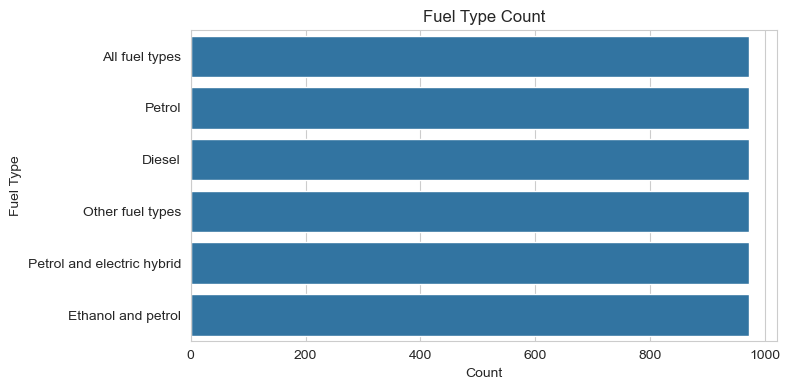

In [9]:
# Figure A.1
plt.figure(figsize=(8,4))
sns.countplot(data=df, y="type_of_fuel", order=df["type_of_fuel"].value_counts().index)
plt.title("Fuel Type Count")
plt.xlabel("Count")
plt.ylabel("Fuel Type")
plt.tight_layout()
plt.show()

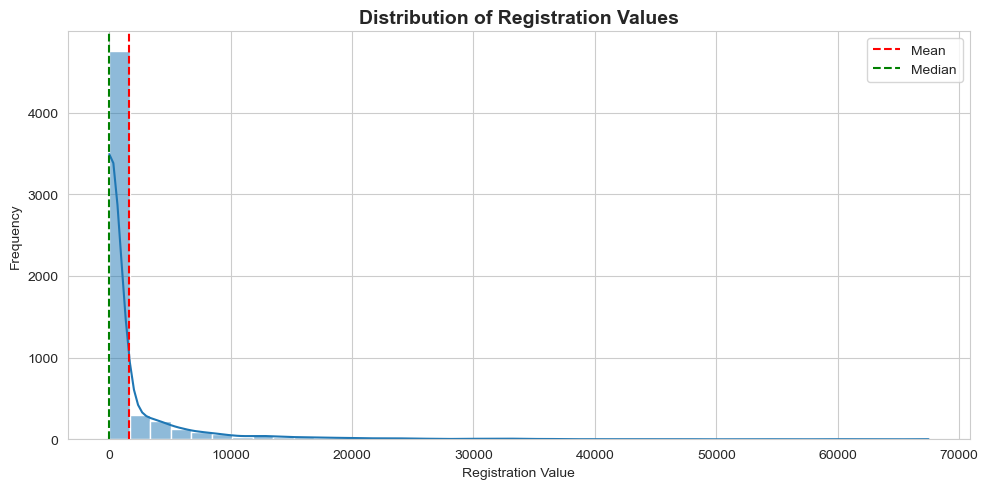

In [10]:
# Figure A.2
plt.figure(figsize=(10,5))
sns.histplot(df["value"], bins=40, kde=True)
plt.title("Distribution of Registration Values", fontsize=14, weight="bold")
plt.xlabel("Registration Value")
plt.ylabel("Frequency")
plt.axvline(df["value"].mean(), color="red", linestyle="--", label="Mean")
plt.axvline(df["value"].median(), color="green", linestyle="--", label="Median")
plt.legend()
plt.tight_layout()
plt.show()

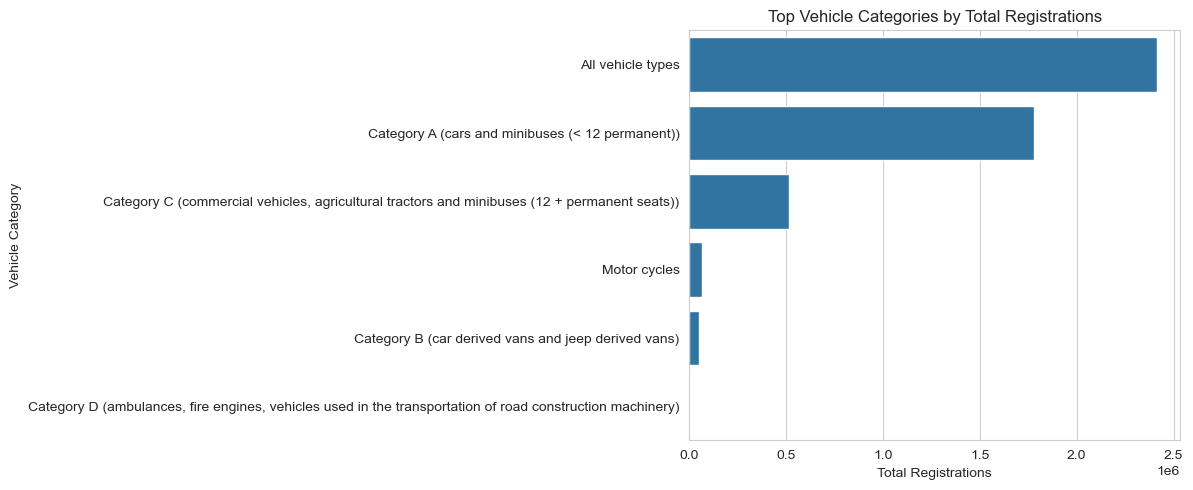

In [11]:
# Figure A.3
cat_total = (
    df[df["statistic_label"] == "All Vehicle Registrations"]
    .groupby("vehicle_category")["value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))
sns.barplot(x=cat_total.values, y=cat_total.index)
plt.title("Top Vehicle Categories by Total Registrations")
plt.xlabel("Total Registrations")
plt.ylabel("Vehicle Category")
plt.tight_layout()
plt.show()

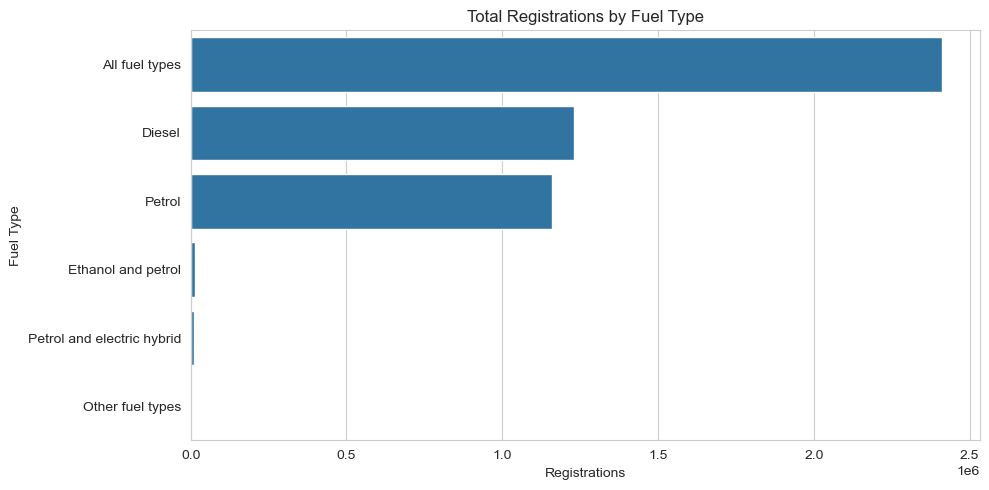

In [12]:
# Figure A.4
fuel_total = (
    df[df["statistic_label"] == "All Vehicle Registrations"]
    .groupby("type_of_fuel")["value"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
sns.barplot(x=fuel_total.values, y=fuel_total.index)
plt.title("Total Registrations by Fuel Type")
plt.xlabel("Registrations")
plt.ylabel("Fuel Type")
plt.tight_layout()
plt.show()

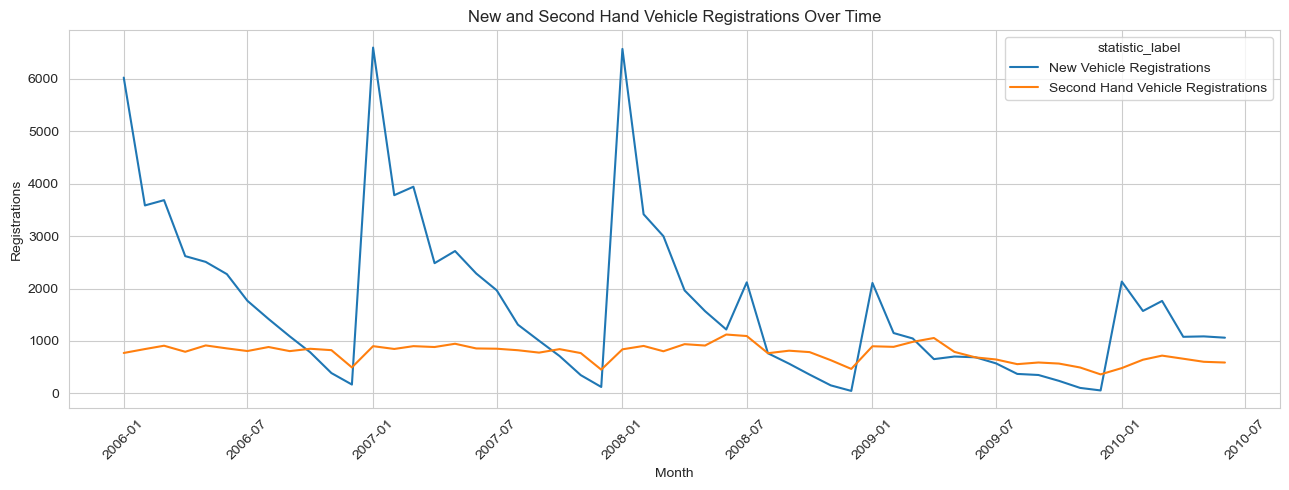

In [13]:
# Figure A.5
temp = df[df["statistic_label"].isin(["New Vehicle Registrations","Second Hand Vehicle Registrations"])].copy()
temp["month_date"] = pd.to_datetime(temp["month"], format="%YM%m")
plt.figure(figsize=(13,5))
sns.lineplot(data=temp, x="month_date", y="value", hue="statistic_label", errorbar=None)
plt.title("New and Second Hand Vehicle Registrations Over Time")
plt.xlabel("Month")
plt.ylabel("Registrations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

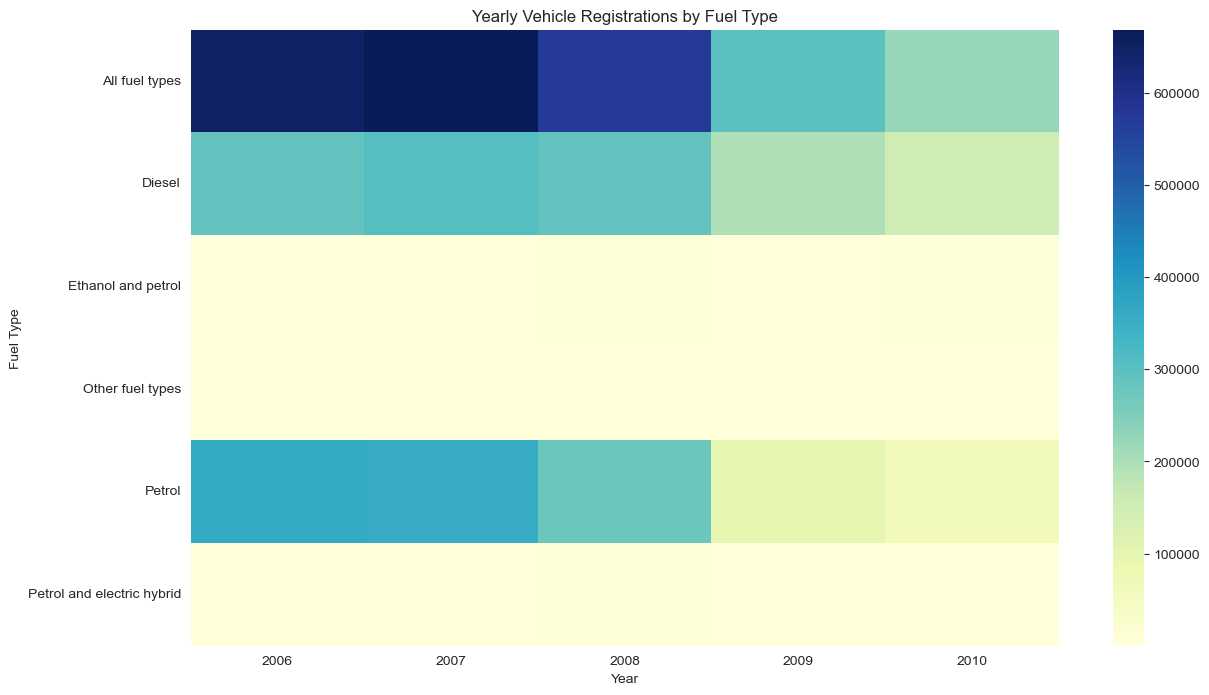

In [14]:
# Figure A.6
temp = df[df["statistic_label"] == "All Vehicle Registrations"].copy()
temp["year"] = temp["month"].str[:4]
pivot = temp.pivot_table(values="value", index="type_of_fuel", columns="year", aggfunc="sum", fill_value=0)
plt.figure(figsize=(14,8))
sns.heatmap(pivot, cmap="YlGnBu", annot=False)
plt.title("Yearly Vehicle Registrations by Fuel Type")
plt.xlabel("Year")
plt.ylabel("Fuel Type")
plt.show()

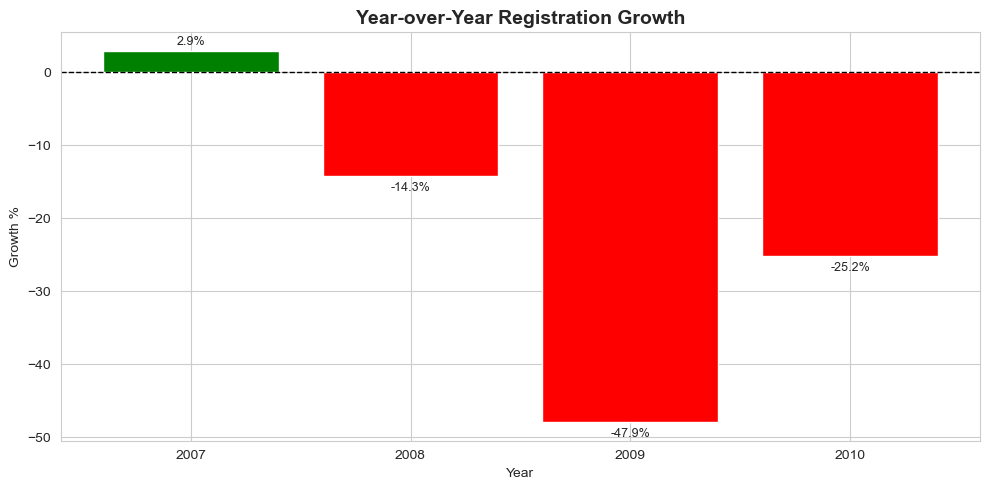

In [15]:
# Figure A.7
temp = df[df["statistic_label"] == "All Vehicle Registrations"].copy()
temp["year"] = temp["month"].str[:4]
yearly = (temp.groupby("year")["value"].sum().pct_change().mul(100).dropna())
colors = np.where(yearly > 0, "green", "red")
plt.figure(figsize=(10,5))
bars = plt.bar(yearly.index, yearly.values, color=colors)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
for bar, val in zip(bars, yearly.values):
    plt.text(bar.get_x() + bar.get_width()/2,val + (0.8 if val > 0 else -2),f"{val:.1f}%",ha="center",fontsize=9)
plt.title("Year-over-Year Registration Growth", fontsize=14, weight="bold")
plt.xlabel("Year")
plt.ylabel("Growth %")
plt.tight_layout()
plt.show()

## Data Cleaning and Feature Engineering

In [16]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)
df = df[df["type_of_fuel"].isin(["Diesel", "Petrol"])].copy()
df["target"] = df["type_of_fuel"].map({
    "Diesel": 0,
    "Petrol": 1
})
df.head()

,c02584v03137,vehicle_category,c01841v02268,type_of_fuel,tlistm1,month,statistic,statistic_label,unit,value,target
162,-,All vehicle types,1,Petrol,200601,2006M01,TDM01C1,All Vehicle Registrations,Number,36501,1
163,-,All vehicle types,1,Petrol,200601,2006M01,TDM01C2,New Vehicle Registrations,Number,32998,1
164,-,All vehicle types,1,Petrol,200601,2006M01,TDM01C3,Second Hand Vehicle Registrations,Number,3503,1
165,-,All vehicle types,1,Petrol,200602,2006M02,TDM01C1,All Vehicle Registrations,Number,23340,1
166,-,All vehicle types,1,Petrol,200602,2006M02,TDM01C2,New Vehicle Registrations,Number,19395,1


In [17]:
drop_cols = ["type_of_fuel","target","c01841v02268","c02584v03137","statistic","unit"]
X = df.drop(columns=drop_cols)
y = df["target"]

In [18]:
X["year"] = X["month"].str[:4].astype(int)
X["month_num"] = X["month"].str[-2:].astype(int)
X["quarter"] = ((X["month_num"] - 1) // 3 + 1).astype(int)

X["value"] = pd.to_numeric(X["value"], errors="coerce")
X["value_log"] = np.log1p(X["value"])
X["value_sqrt"] = np.sqrt(X["value"].clip(lower=0))
X["value_per_year"] = X["value"] / X["year"]

X["is_all_registration"] = (X["statistic_label"] == "All Vehicle Registrations").astype(int)
X["is_new_registration"] = (X["statistic_label"] == "New Vehicle Registrations").astype(int)
X["is_second_hand"] = (X["statistic_label"] == "Second Hand Vehicle Registrations").astype(int)

X = X.drop(columns=["month"])

In [19]:
for col in X.columns:
    if X[col].dtype == "object":
        X[col] = X[col].fillna("missing").astype(str)
    else:
        X[col] = X[col].fillna(X[col].median())

In [20]:
cat_features = X.select_dtypes(include="object").columns.tolist()
num_features = X.select_dtypes(exclude="object").columns.tolist()

cat_features, num_features

(['vehicle_category', 'statistic_label'],
 ['tlistm1',
  'value',
  'year',
  'month_num',
  'quarter',
  'value_log',
  'value_sqrt',
  'value_per_year',
  'is_all_registration',
  'is_new_registration',
  'is_second_hand'])

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Model 1: Cat Boost

In [22]:
cat_model = CatBoostClassifier(
    iterations=2000,
    depth=8,
    learning_rate=0.02,
    l2_leaf_reg=3,
    loss_function="Logloss",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=0
)
cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    use_best_model=True
)

CatBoostClassifier(depth=8, eval_metric='Accuracy', iterations=2000, l2_leaf_reg=3, learning_rate=0.02, loss_function='Logloss', random_seed=42, verbose=0)

In [23]:
cat_proba = cat_model.predict_proba(X_test)[:, 1]

cat_best_accuracy = 0
cat_best_threshold = 0.5

for threshold in np.arange(0.20, 0.81, 0.01):
    cat_temp_pred = (cat_proba >= threshold).astype(int)
    acc = accuracy_score(y_test, cat_temp_pred)

    if acc > cat_best_accuracy:
        cat_best_accuracy = acc
        cat_best_threshold = threshold

cat_pred = (cat_proba >= cat_best_threshold).astype(int)

cat_accuracy = accuracy_score(y_test, cat_pred)
cat_precision = precision_score(y_test, cat_pred)
cat_recall = recall_score(y_test, cat_pred)
cat_f1 = f1_score(y_test, cat_pred)
cat_auc = roc_auc_score(y_test, cat_proba)

cat_accuracy, cat_best_threshold

(0.910025706940874, np.float64(0.5000000000000002))

In [24]:
print(classification_report(y_test, cat_pred, target_names=["Diesel", "Petrol"]))

              precision    recall  f1-score   support

      Diesel       0.93      0.89      0.91       195
      Petrol       0.89      0.93      0.91       194

    accuracy                           0.91       389
   macro avg       0.91      0.91      0.91       389
weighted avg       0.91      0.91      0.91       389



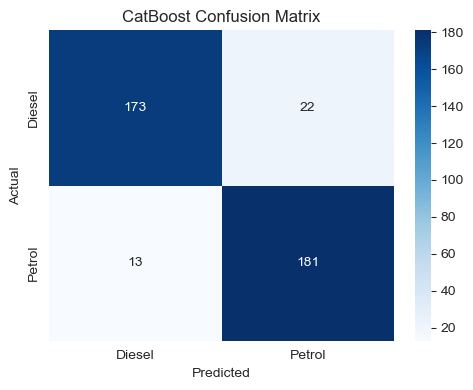

In [25]:
# Figure A.8
cat_cm = confusion_matrix(y_test, cat_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cat_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Diesel", "Petrol"],
            yticklabels=["Diesel", "Petrol"])
plt.title("CatBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Model 2: Extra Trees

In [26]:
extra_preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_features)
])

extra_model = Pipeline([
    ("preprocessor", extra_preprocessor),
    ("model", ExtraTreesClassifier(
        n_estimators=1000,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features=None,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])


In [27]:
extra_model.fit(X_train, y_train)
extra_proba = extra_model.predict_proba(X_test)[:, 1]

extra_best_accuracy = 0
extra_best_threshold = 0.5

for threshold in np.arange(0.20, 0.81, 0.01):
    extra_temp_pred = (extra_proba >= threshold).astype(int)
    acc = accuracy_score(y_test, extra_temp_pred)

    if acc > extra_best_accuracy:
        extra_best_accuracy = acc
        extra_best_threshold = threshold

extra_pred = (extra_proba >= extra_best_threshold).astype(int)

extra_accuracy = accuracy_score(y_test, extra_pred)
extra_precision = precision_score(y_test, extra_pred)
extra_recall = recall_score(y_test, extra_pred)
extra_f1 = f1_score(y_test, extra_pred)
extra_auc = roc_auc_score(y_test, extra_proba)

extra_accuracy, extra_best_threshold

(0.9074550128534704, np.float64(0.34000000000000014))

In [28]:
print(classification_report(y_test, extra_pred, target_names=["Diesel", "Petrol"]))

              precision    recall  f1-score   support

      Diesel       0.95      0.86      0.90       195
      Petrol       0.87      0.96      0.91       194

    accuracy                           0.91       389
   macro avg       0.91      0.91      0.91       389
weighted avg       0.91      0.91      0.91       389



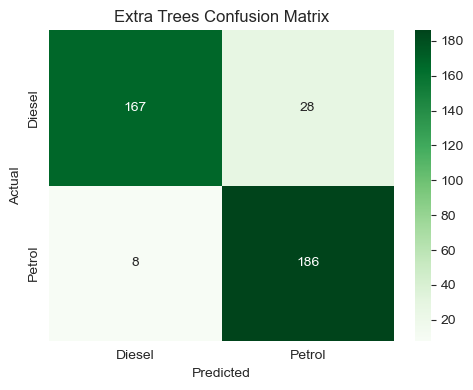

In [29]:
# Figure A.9
extra_cm = confusion_matrix(y_test, extra_pred)

plt.figure(figsize=(5,4))
sns.heatmap(extra_cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Diesel", "Petrol"],
            yticklabels=["Diesel", "Petrol"])
plt.title("Extra Trees Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Cross Validation

In [30]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cat_boost_scores = []

for train_idx, valid_idx in cv.split(X, y):
    X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]

    model = CatBoostClassifier(
        iterations=1000,
        depth=8,
        learning_rate=0.02,
        l2_leaf_reg=3,
        loss_function="Logloss",
        eval_metric="Accuracy",
        random_seed=42,
        verbose=0
    )

    model.fit(X_tr, y_tr, cat_features=cat_features)
    pred = model.predict(X_val)
    cat_boost_scores.append(accuracy_score(y_val, pred))

cat_boost_scores, np.mean(cat_boost_scores)

([0.9125964010282777,
  0.8791773778920309,
  0.9125964010282777,
  0.8920308483290489,
  0.8891752577319587],
 np.float64(0.8971152572019188))

### CV Std = 0.0133

In [31]:
extra_tree_scores = []

for train_idx, valid_idx in cv.split(X, y):
    X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]

    model = Pipeline([
        ("preprocessor", extra_preprocessor),
        ("model", ExtraTreesClassifier(
            n_estimators=1000,
            max_depth=None,
            max_features=None,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ])

    model.fit(X_tr, y_tr)
    pred = model.predict(X_val)
    extra_tree_scores.append(accuracy_score(y_val, pred))

extra_tree_scores, np.mean(extra_tree_scores)

([0.9048843187660668,
  0.8688946015424165,
  0.8997429305912596,
  0.9074550128534704,
  0.8943298969072165],
 np.float64(0.8950613521320859))

### CV Std = 0.0138

## Final Model Comparison

In [32]:
results = pd.DataFrame({
    "Model": ["Cat Boost", "Extra Trees"],
    "Accuracy": [cat_accuracy, extra_accuracy],
    "Precision": [cat_precision, extra_precision],
    "Recall": [cat_recall, extra_recall],
    "F1 Score": [cat_f1, extra_f1],
    "ROC AUC": [cat_auc, extra_auc],
})
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Cat Boost,0.910026,0.891626,0.932990,0.911839,0.975284
1,Extra Trees,0.907455,0.869159,0.958763,0.911765,0.974372


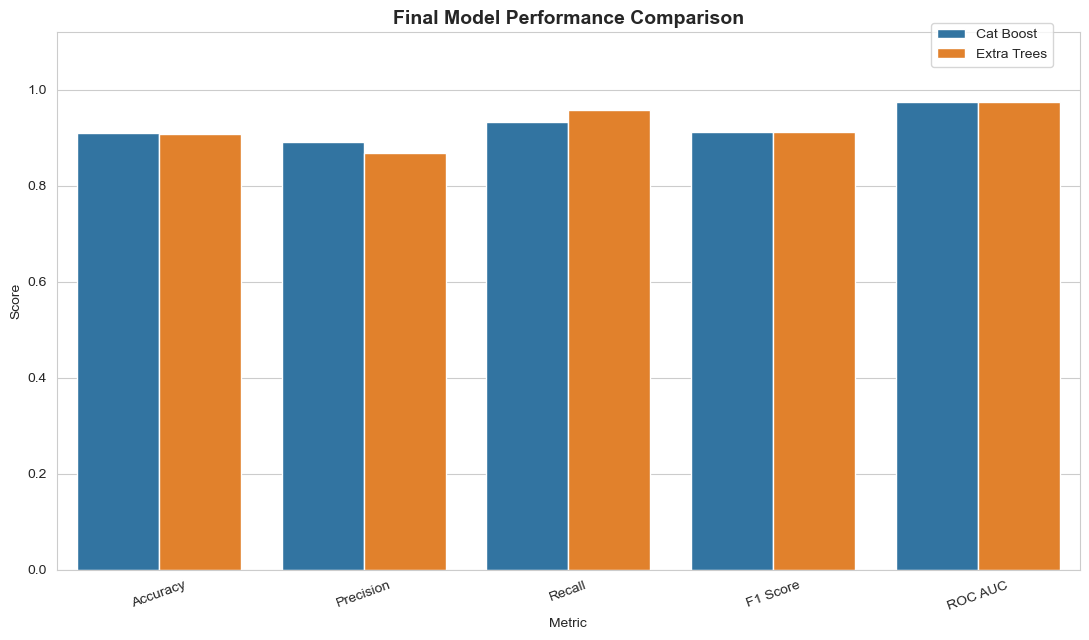

In [33]:
# Figure A.10
metric_plot_df = results.melt(id_vars="Model",var_name="Metric",value_name="Score")
plt.figure(figsize=(11,6.5))
sns.barplot(data=metric_plot_df,x="Metric",y="Score",hue="Model")
plt.ylim(0,1.12)
plt.title("Final Model Performance Comparison", fontsize=14, weight="bold")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.xticks(rotation=20)
plt.legend(loc="upper right",bbox_to_anchor=(0.98,1.03),frameon=True)
plt.tight_layout()
plt.show()